In [5]:
"""
FRACTURE DETECTION – MSc CS PROJECT (FULL PIPELINE + POLISH) with GRAD-CAM++
"""

'\nFRACTURE DETECTION – MSc CS PROJECT (FULL PIPELINE + POLISH) with GRAD-CAM++\n'

In [6]:
# =========================
# IMPORTS
# =========================

import os
import cv2
import json
import numpy as np
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow:", tf.__version__)
print("GPU:", len(tf.config.list_physical_devices("GPU")) > 0)

TensorFlow: 2.19.0
GPU: True


In [7]:
# =========================
# CONFIG
# =========================
CONFIG = {
    "img_size": (224, 224),
    "batch_size": 16,     # reduced for memory safety
    "epochs": 120,
    "learning_rate": 3e-4,
    "test_size": 0.2,
    "seed": 42
}

np.random.seed(CONFIG["seed"])
tf.random.set_seed(CONFIG["seed"])

In [8]:
# =========================
# DATASET PATH (VERIFIED)
# =========================
DATA_DIR = "/kaggle/input/bone-fracture-dataset-1/Ultimate-Mixed-Bone-Fracture-Dataset 1/images"
assert os.path.exists(DATA_DIR), "❌ Dataset path invalid"

print("✅ Dataset found:", DATA_DIR)
print("Classes:", os.listdir(DATA_DIR))

✅ Dataset found: /kaggle/input/bone-fracture-dataset-1/Ultimate-Mixed-Bone-Fracture-Dataset 1/images
Classes: ['Non_fractured', 'Fractured']


In [9]:
# =========================
# PREPROCESSING (EDGE-AWARE)
# =========================
def preprocess_image(path, img_size=CONFIG["img_size"]):
    try:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None or img.size == 0:
            return None
        if img.shape[0] < 50 or img.shape[1] < 50:
            return None

        img = cv2.resize(img, img_size, interpolation=cv2.INTER_LANCZOS4)
        if np.std(img) < 5:
            return None

        clahe = cv2.createCLAHE(2.0, (8,8))
        img = clahe.apply(img)

        edges = cv2.Sobel(img, cv2.CV_32F, 1, 1)
        edges = cv2.normalize(edges, None, 0, 255, cv2.NORM_MINMAX)

        img = 0.8 * img + 0.2 * edges
        img = img.astype(np.float32) / 255.0
        img = np.expand_dims(img, -1)
        return img
    except:
        return None

In [10]:
# =========================
# LOAD DATA
# =========================
X, y = [], []

for cls in os.listdir(DATA_DIR):
    cls_path = os.path.join(DATA_DIR, cls)
    if not os.path.isdir(cls_path):
        continue

    label = 1 if cls.lower().startswith("fract") else 0
    files = [f for f in os.listdir(cls_path)
             if f.lower().endswith(('.png','.jpg','.jpeg','.bmp','.tif','.tiff'))]

    print(f"Loading {cls}: {len(files)} images")

    for f in files:
        img = preprocess_image(os.path.join(cls_path, f))
        if img is not None:
            X.append(img)
            y.append(label)

X = np.array(X)
y = np.array(y)

print("\nDataset loaded")
print("Total images:", len(X))
print("Non-fractured:", np.sum(y==0))
print("Fractured:", np.sum(y==1))
print("Shape:", X.shape)

Loading Non_fractured: 8133 images


Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
P

Loading Fractured: 7323 images


libpng warning: bKGD: invalid
libpng warning: iCCP: profile 'ICC Profile': 0h: PCS illuminant is not D50
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid



Dataset loaded
Total images: 15456
Non-fractured: 8133
Fractured: 7323
Shape: (15456, 224, 224, 1)


In [11]:
# =========================
# TRAIN / TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=CONFIG["test_size"],
    stratify=y,
    random_state=CONFIG["seed"]
)

In [12]:
# =========================
# CLASS WEIGHTS (FN-OPTIMIZED)
# =========================
n0 = np.sum(y_train == 0)
n1 = np.sum(y_train == 1)
total = len(y_train)

class_weight = {
    0: total / (2.0 * n0) * 0.6,
    1: total / (2.0 * n1) * 2.0
}

print("Class weights:", class_weight)

Class weights: {0: np.float64(0.5701198893329235), 1: np.float64(2.110617958347559)}


In [13]:
# =========================
# DATA AUGMENTATION (SOFTER FOR 224x224)
# =========================
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomZoom(0.08),
    layers.RandomContrast(0.12),
])

I0000 00:00:1767604737.788175      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1767604737.791958      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [14]:
# =========================
# MODEL
# =========================
def build_model():
    inputs = layers.Input((224,224,1))
    x = data_augmentation(inputs)

    for filters in [48, 96, 192]:
        x = layers.Conv2D(filters, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Conv2D(filters, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.MaxPooling2D()(x)
        x = layers.Dropout(0.25)(x)

    att = layers.Conv2D(1, 1, activation="sigmoid")(x)
    x = layers.multiply([x, att])

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    return keras.Model(inputs, outputs)

In [15]:
# =========================
# FOCAL LOSS
# =========================
def focal_loss(gamma=2.5, alpha=0.75):
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1-1e-7)
        pt = tf.where(tf.equal(y_true, 1), y_pred, 1-y_pred)
        return -alpha * tf.pow(1-pt, gamma) * tf.math.log(pt)
    return loss

model = build_model()

model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=CONFIG["learning_rate"],
        weight_decay=1e-4
    ),
    loss=focal_loss(),
    metrics=[
        "accuracy",
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc")
    ]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        480 │ sequential[0][0]  │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 224, 224,  │        192 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 224, 224,  │          0 │ batch_normalizat… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 224, 224,  │     20,784 │ re_lu[0][0]       │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        192 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 224, 224,  │          0 │ batch_normalizat… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 112, 112,  │          0 │ max_pooling2d[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 112, 112,  │     41,568 │ dropout[0][0]     │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        384 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 112, 112,  │     83,040 │ re_lu_2[0][0]     │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        384 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ re_lu_3[0][0]   

 Total params: 696,466 (2.66 MB)

 Trainable params: 695,122 (2.65 MB)

 Non-trainable params: 1,344 (5.25 KB)

In [16]:
# =========================
# GRAD-CAM++ IMPLEMENTATION
# =========================
def gradcam_plus_plus(model, img_array, layer_name=None):
    """
    img_array: shape (1, H, W, 1)
    returns heatmap resized to input size
    """

    if layer_name is None:
        # auto-detect last conv layer
        for layer in reversed(model.layers):
            if isinstance(layer, layers.Conv2D):
                layer_name = layer.name
                break

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape1:
        with tf.GradientTape() as tape2:
            with tf.GradientTape() as tape3:
                conv_out, preds = grad_model(img_array)
                loss = preds[:, 0]

            grads = tape3.gradient(loss, conv_out)
        grads2 = tape2.gradient(grads, conv_out)
    grads3 = tape1.gradient(grads2, conv_out)

    conv_out = conv_out[0]
    grads = grads[0]
    grads2 = grads2[0]
    grads3 = grads3[0]

    numerator = grads2
    denominator = 2 * grads2 + conv_out * grads3
    denominator = tf.where(denominator != 0.0, denominator, 1e-10)

    alphas = numerator / denominator
    weights = tf.reduce_sum(alphas * tf.nn.relu(grads), axis=(0, 1))

    cam = tf.reduce_sum(weights * conv_out, axis=-1)
    cam = tf.nn.relu(cam)
    cam = cam / (tf.reduce_max(cam) + 1e-8)

    cam = cv2.resize(cam.numpy(), CONFIG["img_size"])
    return cam

In [17]:
# =========================
# VISUALIZE GRAD-CAM++
# =========================
def show_gradcam(image, heatmap, alpha=0.45):
    """
    image: (H, W, 1) normalized
    heatmap: (H, W)
    """

    image = image.squeeze()
    heatmap = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    base = np.uint8(255 * image)
    base = cv2.cvtColor(base, cv2.COLOR_GRAY2RGB)

    overlay = cv2.addWeighted(base, 1 - alpha, heatmap, alpha, 0)

    plt.figure(figsize=(5,5))
    plt.imshow(overlay)
    plt.axis("off")
    plt.show()

In [18]:
# =========================
# CALLBACKS
# =========================
cb = [
    callbacks.EarlyStopping(
        monitor="val_auc",
        patience=35,
        restore_best_weights=True,
        mode="max"
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=12,
        min_lr=1e-7
    )
]

In [19]:
# =========================
# TRAIN
# =========================
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    class_weight=class_weight,
    callbacks=cb,
    verbose=1
)

Epoch 1/120


E0000 00:00:1767604749.901286      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1767604751.661780     128 cuda_dnn.cc:529] Loaded cuDNN version 91002


773/773 ━━━━━━━━━━━━━━━━━━━━ 222s 271ms/step - accuracy: 0.5277 - auc: 0.7197 - loss: 0.0879 - recall: 0.9491 - val_accuracy: 0.6756 - val_auc: 0.8300 - val_loss: 0.0825 - val_recall: 0.9188 - learning_rate: 3.0000e-04
Epoch 2/120
773/773 ━━━━━━━━━━━━━━━━━━━━ 211s 273ms/step - accuracy: 0.6359 - auc: 0.8294 - loss: 0.0743 - recall: 0.9373 - val_accuracy: 0.5175 - val_auc: 0.8665 - val_loss: 0.1259 - val_recall: 0.9939 - learning_rate: 3.0000e-04
Epoch 3/120
773/773 ━━━━━━━━━━━━━━━━━━━━ 211s 273ms/step - accuracy: 0.6855 - auc: 0.8597 - loss: 0.0692 - recall: 0.9283 - val_accuracy: 0.7044 - val_auc: 0.9029 - val_loss: 0.0906 - val_recall: 0.9631 - learning_rate: 3.0000e-04
Epoch 4/120
773/773 ━━━━━━━━━━━━━━━━━━━━ 212s 274ms/step - accuracy: 0.7281 - auc: 0.8810 - loss: 0.0645 - recall: 0.9199 - val_accuracy: 0.8011 - val_auc: 0.9254 - val_loss: 0.0691 - val_recall: 0.9440 - learning_rate: 3.0000e-04
Epoch 5/120
773/773 ━━━━━━━━━━━━━━━━━━━━ 211s 272ms/step - accuracy: 0.7644 - auc: 0.899

In [20]:
# =========================
# THRESHOLD SWEEP
# =========================
y_prob = model.predict(X_test).flatten()

print("\n🔍 Threshold sweep:\n")
results = []

for t in [0.30,0.35,0.40,0.45,0.50,0.55,0.60]:
    y_pred = (y_prob > t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    acc = (tp + tn) / (tp + tn + fp + fn)
    recall = tp / (tp + fn)
    spec = tn / (tn + fp)

    results.append((t, acc, recall))
    print(f"t={t:.2f} | Acc={acc*100:.2f}% | Recall={recall:.4f} | FP={fp} | FN={fn}")

97/97 ━━━━━━━━━━━━━━━━━━━━ 13s 116ms/step

🔍 Threshold sweep:

t=0.30 | Acc=78.91% | Recall=0.9966 | FP=647 | FN=5
t=0.35 | Acc=82.41% | Recall=0.9925 | FP=533 | FN=11
t=0.40 | Acc=86.32% | Recall=0.9877 | FP=405 | FN=18
t=0.45 | Acc=91.27% | Recall=0.9686 | FP=224 | FN=46
t=0.50 | Acc=93.89% | Recall=0.9440 | FP=107 | FN=82
t=0.55 | Acc=94.18% | Recall=0.9092 | FP=47 | FN=133
t=0.60 | Acc=93.73% | Recall=0.8826 | FP=22 | FN=172


In [21]:
# =========================
# BEST THRESHOLD (BALANCED)
# =========================
best_t, best_acc = 0, 0
for t, acc, recall in results:
    if acc > best_acc and recall > 0.90:
        best_acc = acc
        best_t = t

print(f"\n🎯 Best threshold: {best_t}")
print(f"Accuracy: {best_acc*100:.2f}%")


🎯 Best threshold: 0.55
Accuracy: 94.18%


In [22]:
# =========================
# FINAL EVALUATION
# =========================
y_final = (y_prob > best_t).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_final).ravel()

print("\nFINAL CONFUSION MATRIX")
print(confusion_matrix(y_test, y_final))

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_final, digits=4))

accuracy = (tp + tn) / (tp + tn + fp + fn)
recall = tp / (tp + fn)
specificity = tn / (tn + fp)

print("\nFINAL METRICS")
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Recall (Fracture): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")


FINAL CONFUSION MATRIX
[[1580   47]
 [ 133 1332]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.9224    0.9711    0.9461      1627
           1     0.9659    0.9092    0.9367      1465

    accuracy                         0.9418      3092
   macro avg     0.9441    0.9402    0.9414      3092
weighted avg     0.9430    0.9418    0.9417      3092


FINAL METRICS
Accuracy: 94.18%
Recall (Fracture): 0.9092
Specificity: 0.9711


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
True label: 1 | Predicted probability: 0.6432


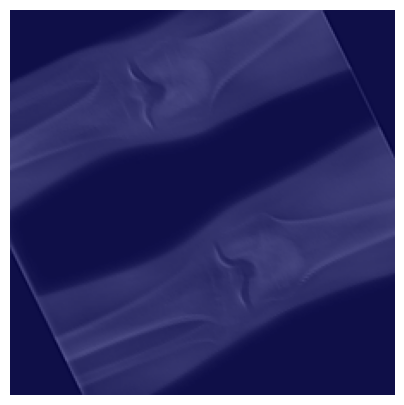

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
True label: 0 | Predicted probability: 0.4981


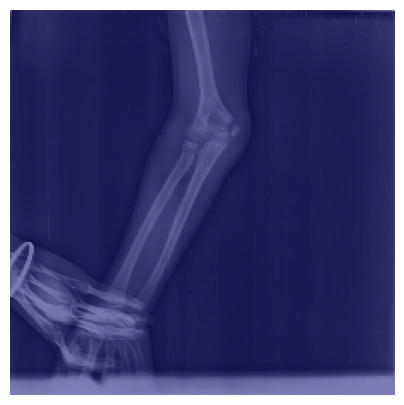

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
True label: 0 | Predicted probability: 0.1083


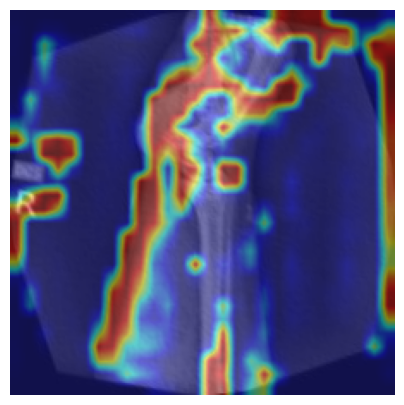

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
True label: 0 | Predicted probability: 0.1053


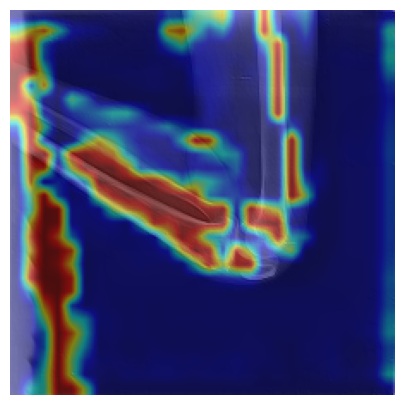

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
True label: 0 | Predicted probability: 0.5064


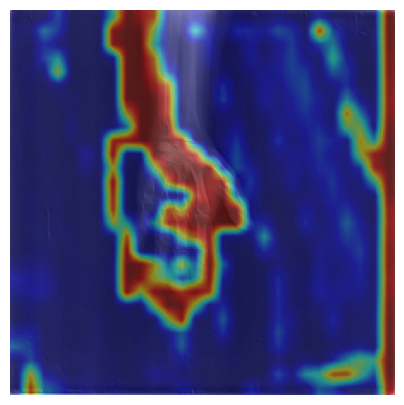

In [23]:
# =========================
# GRAD-CAM++ VISUALIZATION
# =========================
np.random.seed(42)
sample_idxs = np.random.choice(len(X_test), 5, replace=False)

for idx in sample_idxs:
    img = X_test[idx]
    label = y_test[idx]
    prob = model.predict(img[np.newaxis, ...])[0][0]

    heatmap = gradcam_plus_plus(model, img[np.newaxis, ...])

    print(f"True label: {label} | Predicted probability: {prob:.4f}")
    show_gradcam(img, heatmap)

In [24]:
# =========================
# SAVE MODEL + CONFIG
# =========================
model.save("fracture_model_224_final.keras")

with open("deployment_config.json", "w") as f:
    json.dump({
        "best_threshold": best_t,
        "accuracy": float(accuracy),
        "recall": float(recall),
        "specificity": float(specificity)
    }, f, indent=2)

print("\n✅ Model and deployment config saved")


✅ Model and deployment config saved
